In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from utils.parse_results import get_results
import pickle

In [2]:
plt.rcParams.update({
    # 1. Use STIX fonts - these are built-in to Matplotlib
    # and match the 'Times New Roman' / LaTeX serif aesthetic
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    
    # 2. Force the font to be consistent across text and math
    "mathtext.rm": "STIXGeneral",
    "mathtext.it": "STIXGeneral:italic",
    "mathtext.bf": "STIXGeneral:bold",
    
    # 3. Size adjustments for professional legibility
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.titlesize": 12,

    "axes.titleweight": "bold",    # Bold Subplot Titles
    "axes.labelweight": "bold",    # Bold X and Y Labels (e.g., "Performance")
    "font.weight": "bold",
})

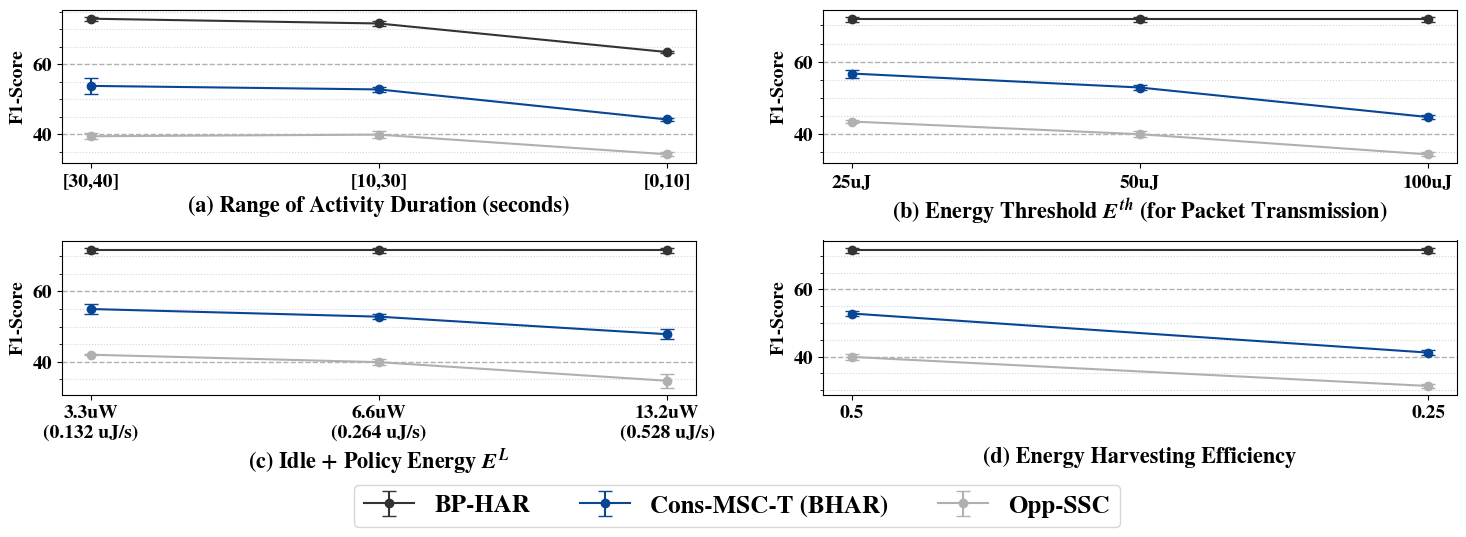

In [3]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# Global configurations
datasets = ["pamap2"]
architectures = ["tinyhar"]
base_path = "../saved_data_cached/results/"
colors = ['#333333', '#084594', '#b0b0b0']
method_labels = ['BP-HAR', 'Cons-MSC-T (BHAR)', 'Opp-SSC']
subplot_labels = ['(a)', '(b)', '(c)', '(d)']

# Define individual plot configurations to loop through
plot_configs = [
    {
        "methods": [
            "unconstrained-synchronous_multisensor_ablation_dur_lower",
            "unconstrained-synchronous_multisensor",
            "unconstrained-synchronous_multisensor_ablation_dur_higher",
            "conservative-asynchronous_multisensor_time_context_ablation_dur_lower",
            "conservative-asynchronous_multisensor_time_context",
            "conservative-asynchronous_multisensor_time_context_ablation_dur_higher",
            "opportunistic-asynchronous_single_sensor_ablation_dur_lower",
            "opportunistic-asynchronous_single_sensor",
            "opportunistic-asynchronous_single_sensor_ablation_dur_higher"
        ],
        "xticks": [0, 1, 2],
        "xtick_labels": ['[30,40]', '[10,30]', '[0,10]'],
        "xlabel": "(a) Range of Activity Duration (seconds)",
        "reverse_data": True,
        "num_points": 3
    },
    {
        "methods": [
            "unconstrained-synchronous_multisensor",
            "unconstrained-synchronous_multisensor",
            "unconstrained-synchronous_multisensor",
            "conservative-asynchronous_multisensor_time_context_ablation_thresh_lower",
            "conservative-asynchronous_multisensor_time_context",
            "conservative-asynchronous_multisensor_time_context_ablation_thresh_higher",
            "opportunistic-asynchronous_single_sensor_ablation_thresh_lower",
            "opportunistic-asynchronous_single_sensor",
            "opportunistic-asynchronous_single_sensor_ablation_thresh_higher"
        ],
        "xticks": [0, 1, 2],
        "xtick_labels": ['25uJ', '50uJ', '100uJ'],
        "xlabel": r"(b) Energy Threshold $E^{th}$ (for Packet Transmission)",
        "reverse_data": False,
        "num_points": 3
    },
    {
        "methods": [
            "unconstrained-synchronous_multisensor",
            "unconstrained-synchronous_multisensor",
            "unconstrained-synchronous_multisensor",
            "conservative-asynchronous_multisensor_time_context_ablation_leakage_lower",
            "conservative-asynchronous_multisensor_time_context",
            "conservative-asynchronous_multisensor_time_context_ablation_leakage_higher",
            "opportunistic-asynchronous_single_sensor_ablation_leakage_lower",
            "opportunistic-asynchronous_single_sensor",
            "opportunistic-asynchronous_single_sensor_ablation_leakage_higher"
        ],
        "xticks": [0, 1, 2],
        "xtick_labels": ['3.3uW\n(0.132 uJ/s)', '6.6uW\n(0.264 uJ/s)', '13.2uW\n(0.528 uJ/s)'],
        "xlabel": r"(c) Idle + Policy Energy $E^{L}$",
        "reverse_data": False,
        "num_points": 3
    },
    {
        "methods": [
            "unconstrained-synchronous_multisensor",
            "unconstrained-synchronous_multisensor",
            "conservative-asynchronous_multisensor_time_context",
            "conservative-asynchronous_multisensor_time_context_ablation_efficiency_lower",
            "opportunistic-asynchronous_single_sensor",
            "opportunistic-asynchronous_single_sensor_ablation_efficiency_lower"
        ],
        "xticks": [0, 1],
        "xtick_labels": ['0.5', '0.25'],
        "xlabel": "(d) Energy Harvesting Efficiency",
        "reverse_data": False,
        "num_points": 2
    }
]

# Create a 2x2 subplot layout with optimized dimensions
fig, axs = plt.subplots(2, 2, figsize=(18, 5))
axs_flat = axs.flatten()  # Flatten array for simple sequential indexing

legend_lines = []

for idx, config in enumerate(plot_configs):
    ax = axs_flat[idx]
    mean_list = []
    std_list = []
    
    # Core Data Processing Block
    for dataset in datasets:
        for architecture in architectures:
            for method in config["methods"]:
                result_path = os.path.join(base_path, dataset, architecture, method)
                result_logs = [os.path.join(result_path, filename) for filename in os.listdir(result_path)]

                results_list = []
                for path in result_logs:
                    with open(path, 'rb') as f:
                        results = pickle.load(f)
                    
                    vals = results.values()
                    results = [np.array(val) for val in vals]
                    results = np.stack(results) 
                    results = np.concatenate([results, np.expand_dims(results[:,2]*results[:,4], 1), np.expand_dims(results[:,3]*results[:,5], 1)], axis=1)
                    results_list.append(results)
                
                results_table = np.stack(results_list)
                subject_means = results_table.mean(axis=1)
                seed_std = subject_means.std(axis=0)
                
                mean_list.append(subject_means.mean(axis=0))
                std_list.append(seed_std)
    
    means = np.stack(mean_list) * 100
    std = np.stack(std_list) * 100
    means[:, np.array([2,3])] /= 100
    std[:, np.array([2,3])] /= 100
    
    # Plotting
    p = config["num_points"]
    for i in range(3):
        y_mean = means[i*p : i*p+p, 0]
        y_std = std[i*p : i*p+p, 0]
        
        if config["reverse_data"]:
            y_mean = y_mean[::-1]
            y_std = y_std[::-1]
            
        line = ax.errorbar(np.arange(p), y_mean, yerr=y_std, fmt='-o', capsize=5, c=colors[i], label=method_labels[i])
        
        if idx == 0:
            legend_lines.append(line)

    # Subplot Styling
    ax.set_xticks(ticks=config["xticks"], labels=config["xtick_labels"], fontsize=14, fontweight='bold')
    ax.set_xlabel(config["xlabel"], fontsize=16, fontweight='bold')
    ax.set_ylabel("F1-Score", fontsize=14, fontweight='bold')
    
    # Set y-ticks font size explicitly to 14
    ax.tick_params(axis='y', labelsize=14)
        
    ax.yaxis.set_minor_locator(AutoMinorLocator(n=4))
    ax.grid(True, which='major', axis='y', linestyle='--', linewidth=1)
    ax.grid(which='minor', axis='y', linestyle=':', linewidth=0.8, color='#d3d3d3')

    # Add (a), (b), (c), (d) to the plots in the top left with big bold text
    # ax.text(-0.075, .88, subplot_labels[idx], transform=ax.transAxes, fontsize=18, fontweight='bold', va='bottom', ha='left')

# Tweak vertical layout space to fit labels nicely between row 1 and row 2
plt.subplots_adjust(hspace=0.5, wspace=0.2)

# Dynamically aligns all x-axis labels across row bounds perfectly
fig.align_xlabels(axs)

# Unified Legend centered nicely underneath both rows
fig.legend(handles=legend_lines, labels=method_labels, loc='lower center', 
           bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=18, frameon=True)

# Save merged visual
plt.savefig("merged_ablations.pdf", bbox_inches='tight')
plt.show()